In [1]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

In [2]:
# 1. Wczytanie pretrenowanego modelu (ResNet18)
model = models.resnet18(pretrained=True)
model.eval()
print("Model ResNet18 został wczytany i ustawiony w tryb ewaluacji.\n")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ResNet18 został wczytany i ustawiony w tryb ewaluacji.



In [3]:
# 2. Przygotowanie transformacji obrazu (ImageNet)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

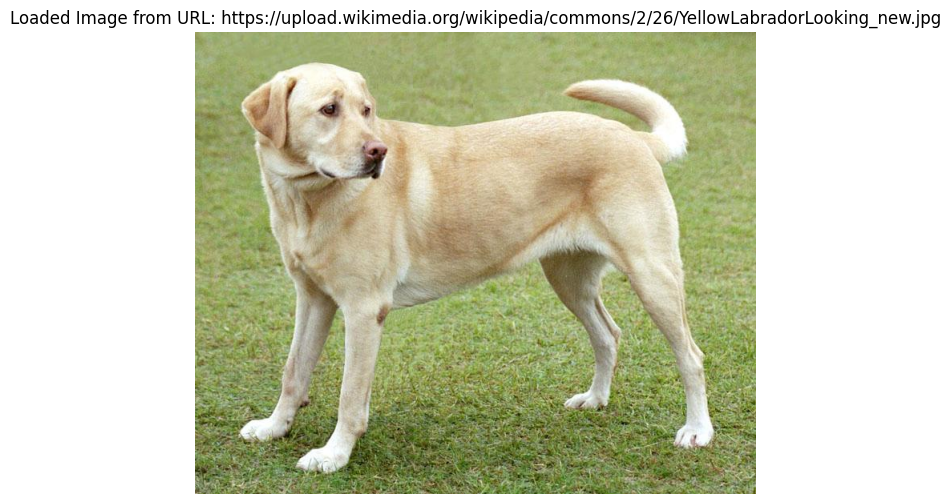

Obrazek został wczytany, wyświetlony i przygotowany do analizy.



In [4]:
url = "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg"

# Dodanie nagłówka User-Agent
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)

response.raise_for_status()  # Raise HTTPError for bad responses (4xx or 5xx)

# Check if content is empty or unexpectedly small before trying to open as image
if not response.content:
    raise ValueError("Pobrany plik jest pusty.")

img = Image.open(BytesIO(response.content)).convert("RGB")

# Display the loaded image as requested in the task
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Loaded Image from URL: {url}")
plt.axis('off')
plt.show()

input_tensor = preprocess(img).unsqueeze(0)  # dodanie wymiaru batch
input_tensor.requires_grad_() # włącz gradienty dla saliency map

print("Obrazek został wczytany, wyświetlony i przygotowany do analizy.\n")

In [5]:
# 4. Predykcja modelu
output = model(input_tensor)
pred_class = output.argmax().item()
print(f"Predykcja modelu (indeks klasy ImageNet): {pred_class}\n")

Predykcja modelu (indeks klasy ImageNet): 208



In [6]:
# --- SALIENCY MAPS ---
# 5. Obliczenie gradientów dla wejścia względem wybranej klasy
model.zero_grad()
output[0, pred_class].backward()
saliency = input_tensor.grad.data.abs().squeeze().max(dim=0)[0].cpu()

print("Mapa saliency została obliczona.\n")

Mapa saliency została obliczona.



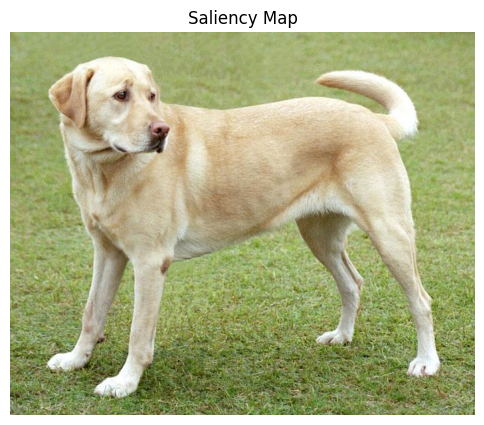

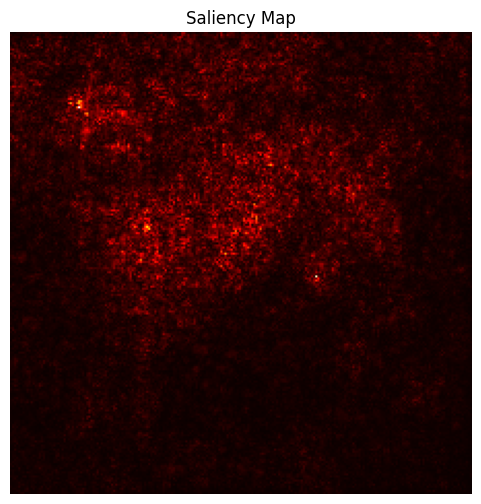

In [7]:
# 6. Wyświetlenie saliency map
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title('Saliency Map')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(saliency, cmap='hot')
plt.axis('off')
plt.title('Saliency Map')
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Predykcja modelu (indeks klasy ImageNet): 208

Mapa Grad-CAM została obliczona i dopasowana do wymiarów obrazka.



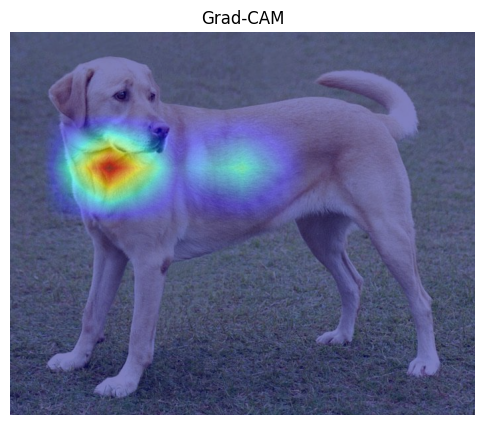

In [17]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# ---------------------------
# 3. Predykcja (This section was already executed, but repeated in the original cell, keeping it as is)
# ---------------------------
output = model(input_tensor)
pred_class = output.argmax().item()
print(f"Predykcja modelu (indeks klasy ImageNet): {pred_class}\n")

# ---------------------------
# 4. Przygotowanie hooków do Grad-CAM
# ---------------------------
last_conv_layer = model.layer4[1].conv2

feature_maps = None
# gradients = None # Removed as per instructions

def forward_hook(module, input, output):
    global feature_maps
    feature_maps = output
    feature_maps.retain_grad() # Added to retain gradients

# Removed backward_hook function and its registration
# def backward_hook(module, grad_in, grad_out):
#     global gradients
#     gradients = grad_out[0]

last_conv_layer.register_forward_hook(forward_hook)
# last_conv_layer.register_backward_hook(backward_hook) # Removed as per instructions

# ---------------------------
# 5. Forward i backward pass
# ---------------------------
model.zero_grad()
# Perform a forward pass again to get the feature maps with retained gradients
output = model(input_tensor)
score = output[0, pred_class]
score.backward()

# ---------------------------
# 6. Obliczenie Grad-CAM
# ---------------------------
# Wagi = średnia gradientów po wysokości i szerokości
weights = torch.mean(feature_maps.grad, dim=(1,2), keepdim=True) # Replaced 'gradients' with 'feature_maps.grad'

# Mnożenie przez feature maps i sumowanie po kanałach
grad_cam_map = F.relu(torch.sum(weights * feature_maps, dim=1))

# Interpolacja do wymiarów oryginalnego obrazka
grad_cam_map = F.interpolate(
    grad_cam_map.unsqueeze(1),
    size=(img.height, img.width),
    mode='bilinear',
    align_corners=False
).squeeze()

# Normalizacja 0-1
grad_cam_map = grad_cam_map / grad_cam_map.max()

print("Mapa Grad-CAM została obliczona i dopasowana do wymiarów obrazka.\n")

# ---------------------------
# 7. Wyświetlenie Grad-CAM na obrazku
# ---------------------------
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.imshow(grad_cam_map.detach().cpu().numpy(), cmap='jet', alpha=0.5)
plt.axis('off')
plt.title('Grad-CAM')
plt.show()